# Set Working Directory



In [1]:
import sys
from pathlib import Path

# Add the parent directory to the system path
sys.path.append(str(Path.cwd().parent.resolve()))

# Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from plotly.subplots import make_subplots
from sklearn.tree import DecisionTreeRegressor
from prettytable.prettytable import PrettyTable
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)

# Data Paths

In [3]:
path = str(Path.cwd().parent.resolve())
demand_data_path = path + "/data/DMA_NetFlow.csv"
weather_data_path = path + "/data/Weather_Data.csv"

# Read Data & Summary


In [4]:
demand_data = pd.read_csv(
    demand_data_path,
    parse_dates=["timestamp"],
    date_format="%d/%m/%Y %H:%M",
    index_col="timestamp",
).loc["2021-01-01 00:00:00":"2022-01-31 00:00:00", :]

weather_data = pd.read_csv(
    weather_data_path,
    parse_dates=["timestamp"],
    date_format="%d/%m/%Y %H:%M",
    index_col="timestamp",
).loc["2021-01-01 00:00:00":"2022-01-31 00:00:00", :]

In [5]:
# Display the first few rows of the demand data
demand_data.head()

,dma_1,dma_2,dma_3,dma_4,dma_5,dma_6,dma_7,dma_8,dma_9,dma_10
timestamp,,,,,,,,,,
2021-01-01 00:00:00,NaN,NaN,3.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00,NaN,NaN,3.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 02:00:00,NaN,NaN,3.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 03:00:00,NaN,NaN,2.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 04:00:00,NaN,NaN,2.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Display the first few rows of the weather data
weather_data.head()

,rainfall_depth,air_temperature,air_humidity,wind_speed
timestamp,,,,
2021-01-01 00:00:00,0.0,7.2,79.0,9.0
2021-01-01 01:00:00,0.0,7.3,79.0,6.0
2021-01-01 02:00:00,0.0,7.6,78.0,4.0
2021-01-01 03:00:00,0.0,8.2,75.0,4.0
2021-01-01 04:00:00,0.0,7.7,77.0,7.0


# Join the data sets

In [7]:
dma_name = "dma_3"
merged_data = pd.merge_asof(
    demand_data.loc[:, [dma_name]].sort_index(),
    weather_data.sort_index(),
    left_index=True,
    right_index=True,
    direction="nearest",
)
merged_data.head(5)

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed
timestamp,,,,,
2021-01-01 00:00:00,3.70,0.0,7.2,79.0,9.0
2021-01-01 01:00:00,3.56,0.0,7.3,79.0,6.0
2021-01-01 02:00:00,3.27,0.0,7.6,78.0,4.0
2021-01-01 03:00:00,2.84,0.0,8.2,75.0,4.0
2021-01-01 04:00:00,2.74,0.0,7.7,77.0,7.0


In [8]:
merged_data.tail(5)

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed
timestamp,,,,,
2022-01-30 20:00:00,4.52,0.0,6.6,85.0,5.0
2022-01-30 21:00:00,4.06,0.0,7.0,82.0,6.0
2022-01-30 22:00:00,3.39,0.0,6.4,78.0,4.0
2022-01-30 23:00:00,3.14,0.0,6.1,81.0,7.0
2022-01-31 00:00:00,2.76,0.0,5.3,80.0,6.0


In [9]:
# Convert data to long format for plotting
data_melted = merged_data.reset_index().melt(
    id_vars="timestamp", var_name="Variable", value_name="Value"
)

# Plot the demand data each variable per subplot
fig = px.line(
    data_melted,
    x="timestamp",
    y="Value",
    color="Variable",
    facet_col="Variable",
    facet_col_wrap=1,
    facet_row_spacing=0.02,
)

fig.update_layout(
    height=1200,
    title_text="Demand and Weather Data Over Time",
)

fig.update_yaxes(matches=None)
fig.show()

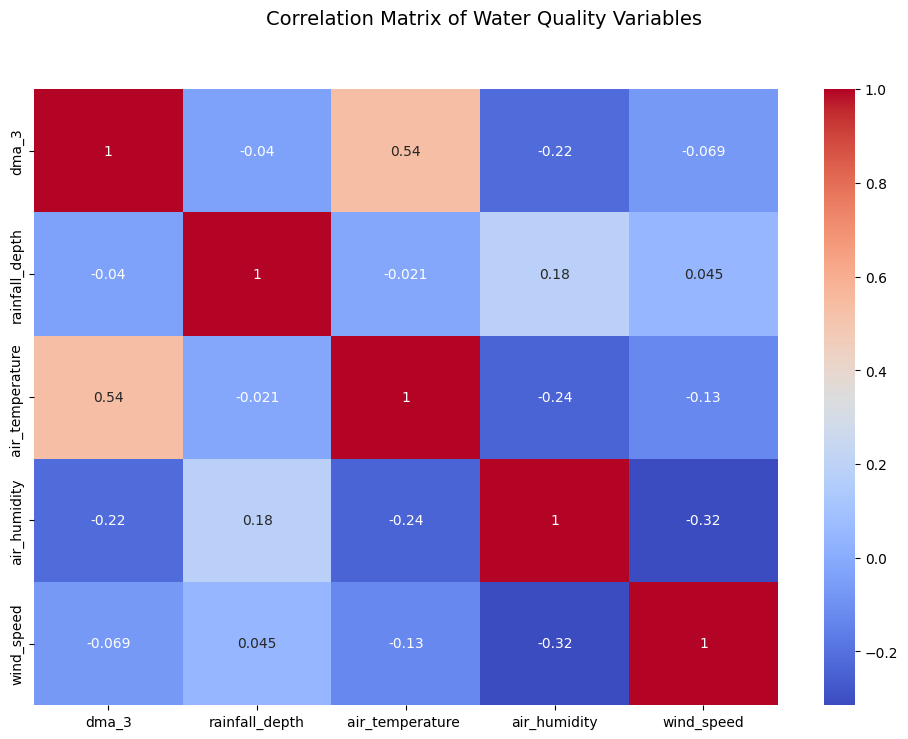

In [10]:
corr_matrix = merged_data.corr()

figure, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
figure.suptitle("Correlation Matrix of Water Quality Variables", fontsize=14)
plt.show()

# Time Feature Engineering

In [11]:
# time-based features
merged_data["hour"] = merged_data.index.hour
merged_data["day_of_week"] = merged_data.index.dayofweek
merged_data["month"] = merged_data.index.month
merged_data["day_of_year"] = merged_data.index.dayofyear
merged_data["week_of_year"] = merged_data.index.isocalendar().week
merged_data["day_of_month"] = merged_data.index.day
merged_data["is_weekend"] = merged_data["day_of_week"].isin([5, 6]).astype(int)
merged_data["season"] = merged_data["month"].apply(lambda x: (x % 12 + 3) // 3)
merged_data["hour_sin"] = np.sin(2 * np.pi * merged_data["hour"] / 24)
merged_data["hour_cos"] = np.cos(2 * np.pi * merged_data["hour"] / 24)
merged_data["day_of_week_sin"] = np.sin(2 * np.pi * merged_data["day_of_week"] / 7)
merged_data["day_of_week_cos"] = np.cos(2 * np.pi * merged_data["day_of_week"] / 7)
merged_data["month_sin"] = np.sin(2 * np.pi * merged_data["month"] / 12)
merged_data["month_cos"] = np.cos(2 * np.pi * merged_data["month"] / 12)
merged_data["day_of_year_sin"] = np.sin(2 * np.pi * merged_data["day_of_year"] / 365)
merged_data["day_of_year_cos"] = np.cos(2 * np.pi * merged_data["day_of_year"] / 365)
merged_data["week_of_year_sin"] = np.sin(2 * np.pi * merged_data["week_of_year"] / 52)
merged_data["week_of_year_cos"] = np.cos(2 * np.pi * merged_data["week_of_year"] / 52)
merged_data["day_of_month_sin"] = np.sin(2 * np.pi * merged_data["day_of_month"] / 31)
merged_data["day_of_month_cos"] = np.cos(2 * np.pi * merged_data["day_of_month"] / 31)

# lagged features
for lag in range(0, 5):
    merged_data[f"{dma_name}_lag_{lag + 1}"] = merged_data[dma_name].shift(lag + 1)

merged_data.head()

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed,hour,day_of_week,month,day_of_year,week_of_year,...,day_of_year_cos,week_of_year_sin,week_of_year_cos,day_of_month_sin,day_of_month_cos,dma_3_lag_1,dma_3_lag_2,dma_3_lag_3,dma_3_lag_4,dma_3_lag_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,3.70,0.0,7.2,79.0,9.0,0,4,1,1,53,...,0.999852,0.120537,0.992709,0.201299,0.97953,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00,3.56,0.0,7.3,79.0,6.0,1,4,1,1,53,...,0.999852,0.120537,0.992709,0.201299,0.97953,3.70,NaN,NaN,NaN,NaN
2021-01-01 02:00:00,3.27,0.0,7.6,78.0,4.0,2,4,1,1,53,...,0.999852,0.120537,0.992709,0.201299,0.97953,3.56,3.70,NaN,NaN,NaN
2021-01-01 03:00:00,2.84,0.0,8.2,75.0,4.0,3,4,1,1,53,...,0.999852,0.120537,0.992709,0.201299,0.97953,3.27,3.56,3.70,NaN,NaN
2021-01-01 04:00:00,2.74,0.0,7.7,77.0,7.0,4,4,1,1,53,...,0.999852,0.120537,0.992709,0.201299,0.97953,2.84,3.27,3.56,3.7,NaN


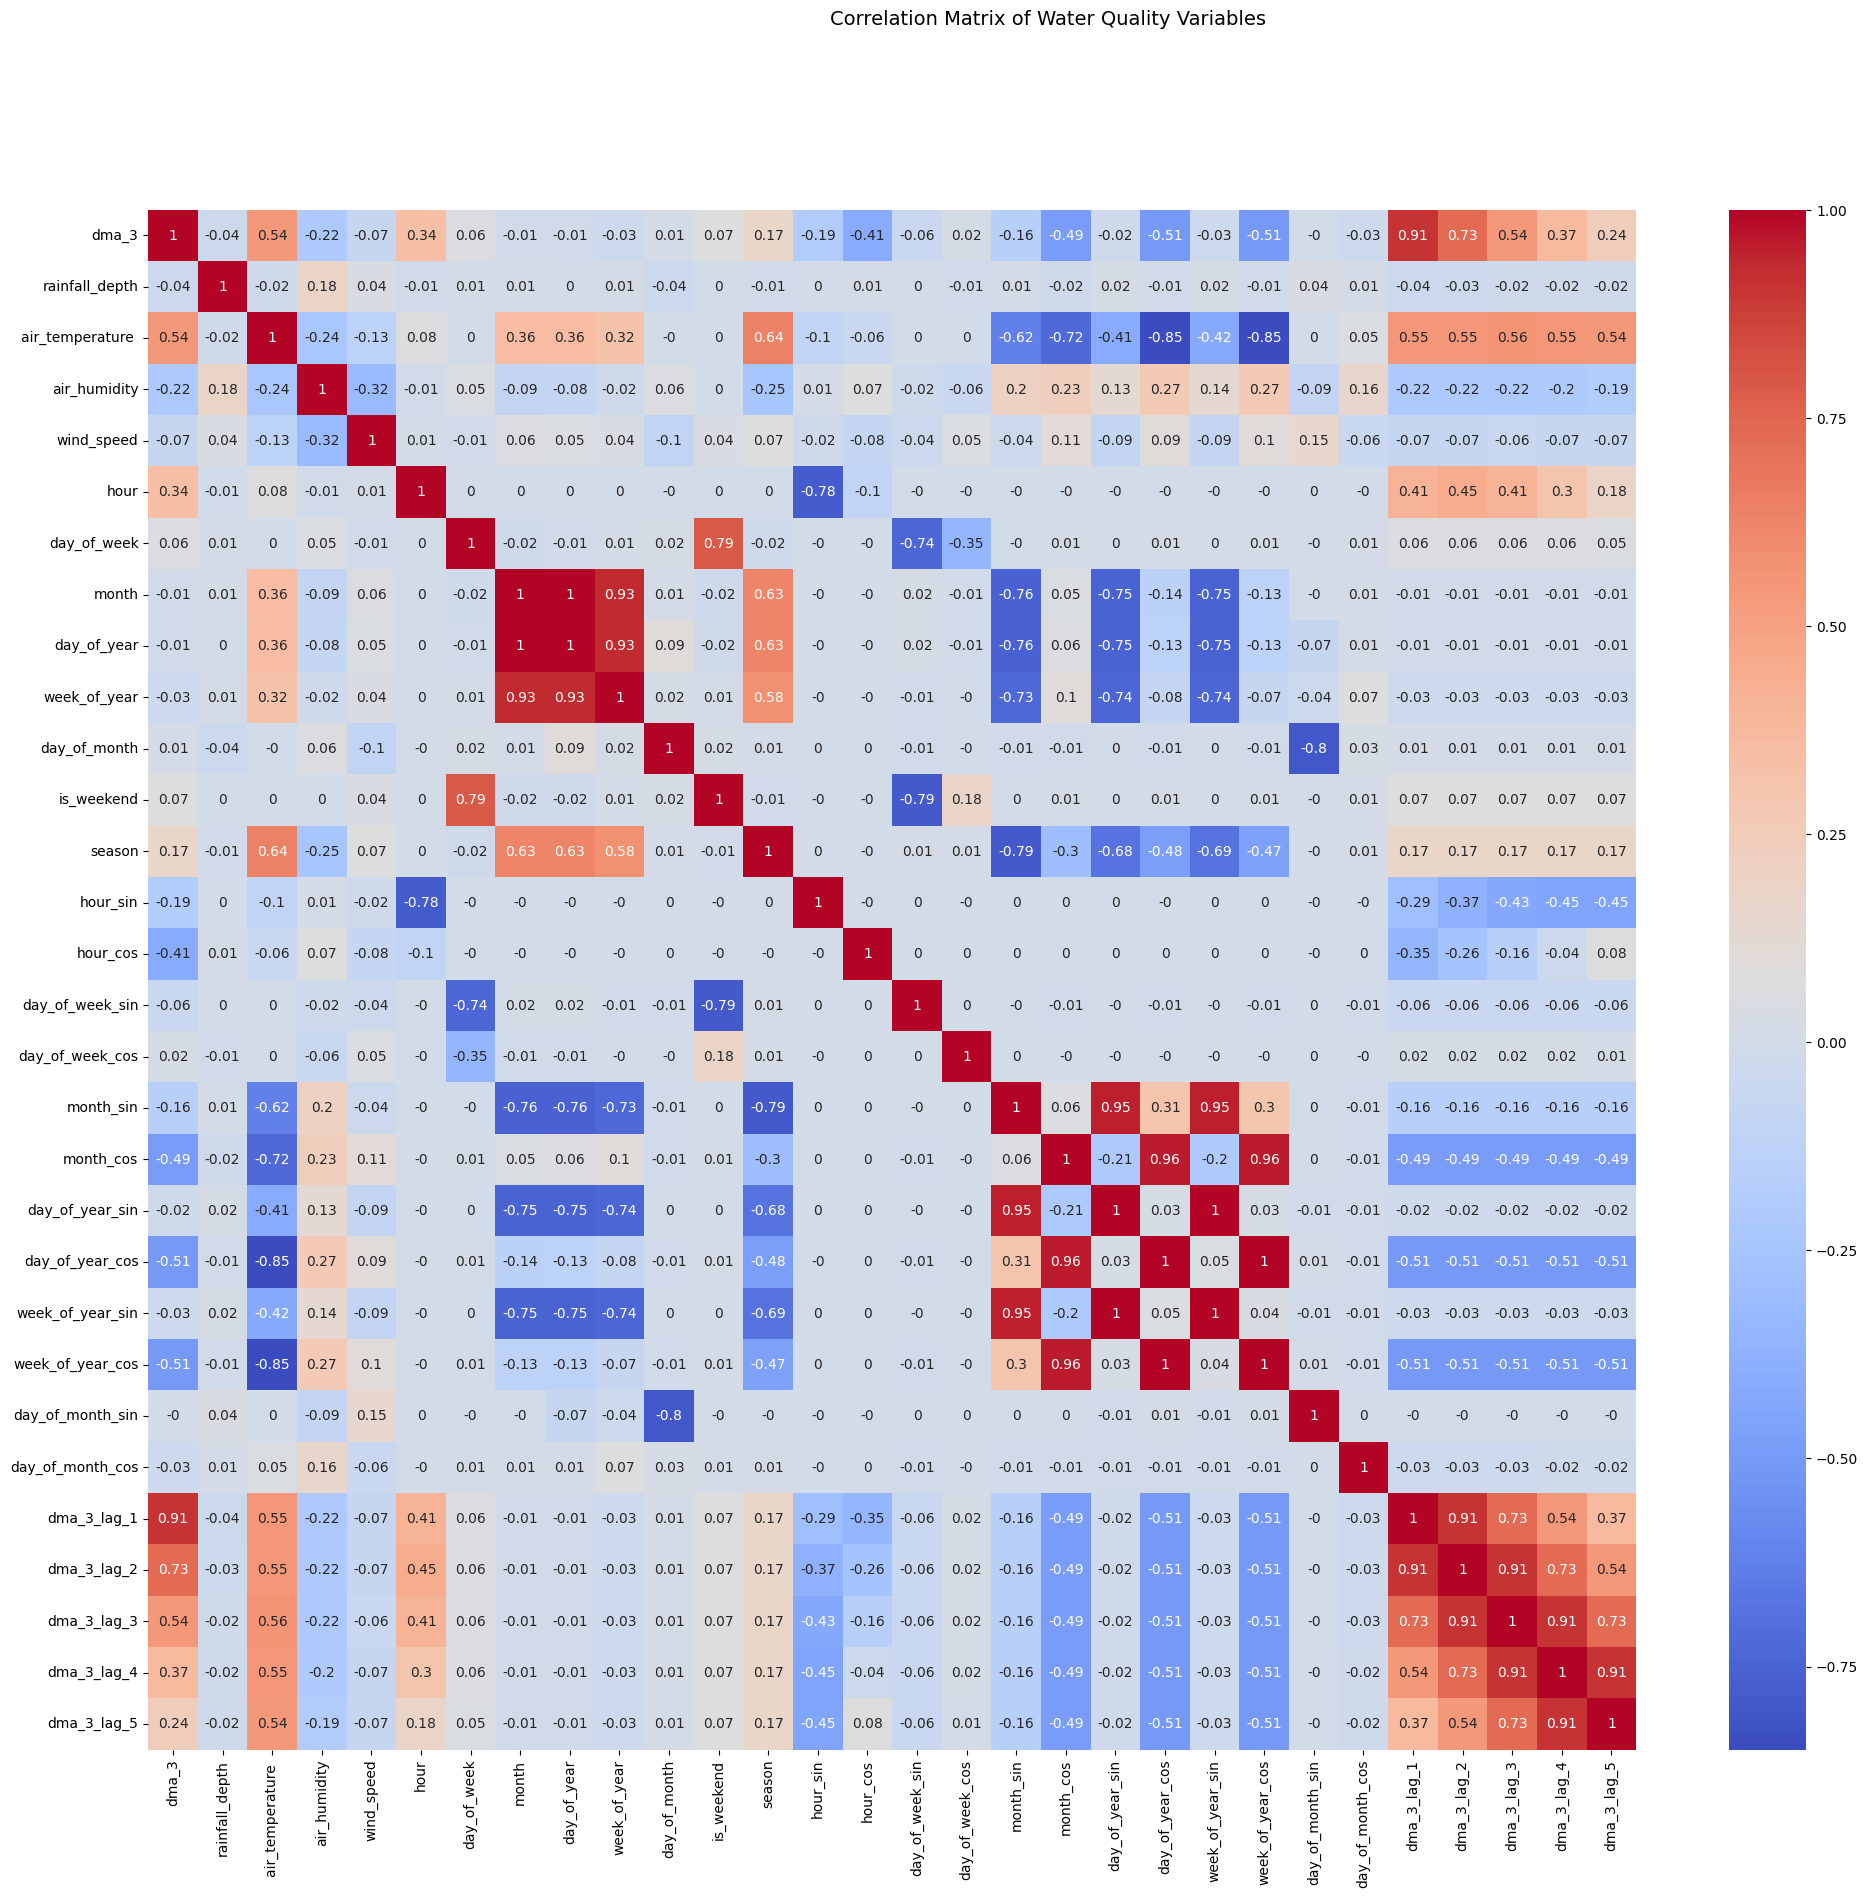

In [12]:
corr_matrix = merged_data.corr().round(2)

figure, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
figure.suptitle("Correlation Matrix of Water Quality Variables", fontsize=14)
plt.show()

# Prepare Data

In [13]:
# Curate training and testing datasets
training_data = merged_data.loc["2021-01-01 00:00:00":"2021-12-31 23:59:00", :]
testing_data = merged_data.loc["2022-01-01 00:00:00":"2022-01-31 23:59:00", :]

# Display the shapes of the training and testing datasets
print(f"Training data shape: {training_data.shape}")
print(f"Testing data shape: {testing_data.shape}")

Training data shape: (8760, 30)
Testing data shape: (721, 30)


In [14]:
# Check for missing values in the training datasets
training_data.isnull().sum().to_frame(name="Missing Values").T

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed,hour,day_of_week,month,day_of_year,week_of_year,...,day_of_year_cos,week_of_year_sin,week_of_year_cos,day_of_month_sin,day_of_month_cos,dma_3_lag_1,dma_3_lag_2,dma_3_lag_3,dma_3_lag_4,dma_3_lag_5
Missing Values,80,1,1,651,13,0,0,0,0,0,...,0,0,0,0,0,81,82,83,84,85


In [15]:
# Check for missing values in the testing datasets
testing_data.isnull().sum().to_frame(name="Missing Values").T

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed,hour,day_of_week,month,day_of_year,week_of_year,...,day_of_year_cos,week_of_year_sin,week_of_year_cos,day_of_month_sin,day_of_month_cos,dma_3_lag_1,dma_3_lag_2,dma_3_lag_3,dma_3_lag_4,dma_3_lag_5
Missing Values,3,0,0,9,0,0,0,0,0,0,...,0,0,0,0,0,3,3,3,3,3


# Missing Data Imputation

In [16]:
# Impute missing values
training_data_imputed = training_data.interpolate(
    method="time", limit_direction="both", inplace=False
)
training_data_imputed.isnull().sum().to_frame(name="Missing Values").T

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed,hour,day_of_week,month,day_of_year,week_of_year,...,day_of_year_cos,week_of_year_sin,week_of_year_cos,day_of_month_sin,day_of_month_cos,dma_3_lag_1,dma_3_lag_2,dma_3_lag_3,dma_3_lag_4,dma_3_lag_5
Missing Values,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
testing_data_imputed = testing_data.interpolate(
    method="time", limit_direction="both", inplace=False
)
testing_data_imputed.isnull().sum().to_frame(name="Missing Values").T

,dma_3,rainfall_depth,air_temperature,air_humidity,wind_speed,hour,day_of_week,month,day_of_year,week_of_year,...,day_of_year_cos,week_of_year_sin,week_of_year_cos,day_of_month_sin,day_of_month_cos,dma_3_lag_1,dma_3_lag_2,dma_3_lag_3,dma_3_lag_4,dma_3_lag_5
Missing Values,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Predictors and Response Variables

In [18]:
predictor_variables = training_data_imputed.columns.difference([dma_name])
response_variables = [dma_name]

x_train = training_data_imputed[predictor_variables]
y_train = training_data_imputed[response_variables]

x_test = testing_data_imputed[predictor_variables]
y_test = testing_data_imputed[response_variables]

# Feature Selection

In [19]:
# Random Forest Regression Feature Selection
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(x_train, y_train.values.ravel())

# Feature importance scores
feature_importances_df = pd.DataFrame(
    rf_regressor.feature_importances_, index=predictor_variables, columns=["Importance"]
)
feature_importances_df.sort_values(by="Importance", ascending=False, inplace=True)
print(feature_importances_df)

                  Importance
dma_3_lag_1         0.816251
hour_sin            0.049004
hour_cos            0.044639
dma_3_lag_3         0.011398
day_of_year         0.009454
air_temperature     0.009243
dma_3_lag_2         0.008160
hour                0.007310
dma_3_lag_4         0.006801
day_of_year_cos     0.005516
dma_3_lag_5         0.004710
day_of_month_sin    0.003055
day_of_year_sin     0.002970
air_humidity        0.002965
wind_speed          0.002862
day_of_month        0.002314
day_of_week         0.002213
day_of_week_sin     0.002154
day_of_month_cos    0.002022
week_of_year_cos    0.001459
week_of_year        0.001307
week_of_year_sin    0.000960
day_of_week_cos     0.000813
month_cos           0.000782
is_weekend          0.000687
month_sin           0.000364
month               0.000298
rainfall_depth      0.000172
season              0.000120


In [20]:
# Automate selection based on the median importance threshold
selector = SelectFromModel(rf_regressor, threshold="median", prefit=True)
selected_features = np.array(predictor_variables)[selector.get_support()]
selected_features_df = feature_importances_df.loc[selected_features].sort_values(
    by="Importance", ascending=False
)
print(selected_features_df)

print(
    f"\n Selected {len(selected_features)} of {len(predictor_variables)} features based on median importance threshold"
)

                  Importance
dma_3_lag_1         0.816251
hour_sin            0.049004
hour_cos            0.044639
dma_3_lag_3         0.011398
day_of_year         0.009454
air_temperature     0.009243
dma_3_lag_2         0.008160
hour                0.007310
dma_3_lag_4         0.006801
day_of_year_cos     0.005516
dma_3_lag_5         0.004710
day_of_month_sin    0.003055
day_of_year_sin     0.002970
air_humidity        0.002965
wind_speed          0.002862

 Selected 15 of 29 features based on median importance threshold


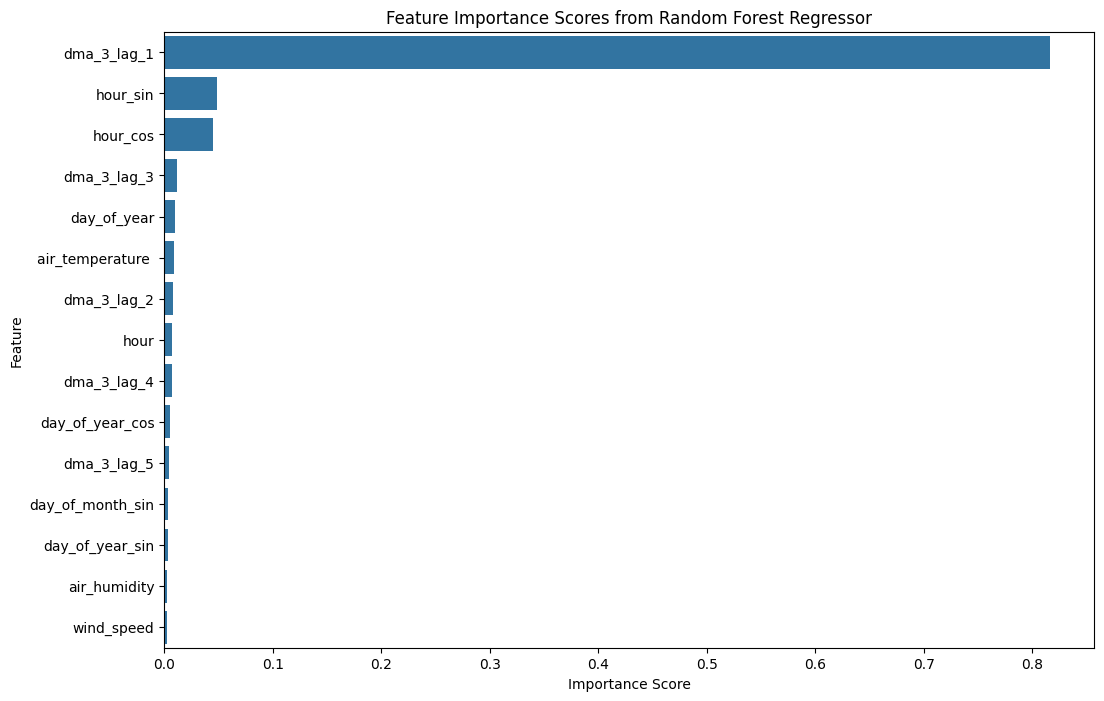

In [21]:
# Plot feature importance scores
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y=selected_features_df.index, data=selected_features_df)
plt.title("Feature Importance Scores from Random Forest Regressor")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [22]:
# Final training and testing datasets with the selected features
x_train_selected_features = x_train[selected_features]
x_test_selected_features = testing_data_imputed[selected_features]
y_train_flattened = y_train.values.ravel()
y_test_flattened = y_test.values.ravel()

# Build Models

In [23]:
linear_model = Pipeline([("scaler", StandardScaler()), ("regressor", LinearRegression())])
linear_model.fit(x_train_selected_features, y_train_flattened)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['air_humidity','air_temperature ','day_of_month_sin',...,'hour_cos', 'hour_sin','wind_speed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [24]:
knn_model = Pipeline(
    [("scaler", StandardScaler()), ("regressor", KNeighborsRegressor(n_neighbors=5))]
)
knn_model.fit(x_train_selected_features, y_train_flattened)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['air_humidity','air_temperature ','day_of_month_sin',...,'hour_cos', 'hour_sin','wind_speed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [25]:
decision_tree_model = Pipeline(
    [("scaler", StandardScaler()), ("regressor", DecisionTreeRegressor(random_state=42))]
)
decision_tree_model.fit(x_train_selected_features, y_train_flattened)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['air_humidity','air_temperature ','day_of_month_sin',...,'hour_cos', 'hour_sin','wind_speed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [26]:
random_forest_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", RandomForestRegressor(n_estimators=100, random_state=42)),
    ]
)
random_forest_model.fit(x_train_selected_features, y_train_flattened)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['air_humidity','air_temperature ','day_of_month_sin',...,'hour_cos', 'hour_sin','wind_speed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [27]:
mlp_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "regressor",
            MLPRegressor(
                hidden_layer_sizes=(100,),
                solver="adam",
                activation="tanh",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)
mlp_model.fit(x_train_selected_features, y_train_flattened)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['air_humidity','air_temperature ','day_of_month_sin',...,'hour_cos', 'hour_sin','wind_speed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


# Test Models

In [28]:
x_pred_linear = linear_model.predict(x_test_selected_features)
linear_mae = mean_absolute_error(y_test_flattened, x_pred_linear, multioutput="raw_values")
linear_mse = mean_squared_error(y_test_flattened, x_pred_linear, multioutput="raw_values")
linear_rmse = root_mean_squared_error(y_test_flattened, x_pred_linear, multioutput="raw_values")
linear_r2 = r2_score(y_test_flattened, x_pred_linear, multioutput="raw_values")

x_pred_knn = knn_model.predict(x_test_selected_features)
knn_mae = mean_absolute_error(y_test_flattened, x_pred_knn, multioutput="raw_values")
knn_mse = mean_squared_error(y_test_flattened, x_pred_knn, multioutput="raw_values")
knn_rmse = root_mean_squared_error(y_test_flattened, x_pred_knn, multioutput="raw_values")
knn_r2 = r2_score(y_test_flattened, x_pred_knn, multioutput="raw_values")

x_pred_decision_tree = decision_tree_model.predict(x_test_selected_features)
decision_tree_mae = mean_absolute_error(
    y_test_flattened, x_pred_decision_tree, multioutput="raw_values"
)
decision_tree_mse = mean_squared_error(
    y_test_flattened, x_pred_decision_tree, multioutput="raw_values"
)
decision_tree_rmse = root_mean_squared_error(
    y_test_flattened, x_pred_decision_tree, multioutput="raw_values"
)
decision_tree_r2 = r2_score(y_test_flattened, x_pred_decision_tree, multioutput="raw_values")

x_pred_random_forest = random_forest_model.predict(x_test_selected_features)
random_forest_mae = mean_absolute_error(
    y_test_flattened, x_pred_random_forest, multioutput="raw_values"
)
random_forest_mse = mean_squared_error(
    y_test_flattened, x_pred_random_forest, multioutput="raw_values"
)
random_forest_rmse = root_mean_squared_error(
    y_test_flattened, x_pred_random_forest, multioutput="raw_values"
)
random_forest_r2 = r2_score(y_test_flattened, x_pred_random_forest, multioutput="raw_values")

x_pred_mlp = mlp_model.predict(x_test_selected_features)
mlp_mae = mean_absolute_error(y_test_flattened, x_pred_mlp, multioutput="raw_values")
mlp_mse = mean_squared_error(y_test_flattened, x_pred_mlp, multioutput="raw_values")
mlp_rmse = root_mean_squared_error(y_test_flattened, x_pred_mlp, multioutput="raw_values")
mlp_r2 = r2_score(y_test_flattened, x_pred_mlp, multioutput="raw_values")

# Print Results

In [29]:
tables = [
    ["MAE", linear_mae, knn_mae, decision_tree_mae, random_forest_mae, mlp_mae],
    ["MSE", linear_mse, knn_mse, decision_tree_mse, random_forest_mse, mlp_mse],
    ["RMSE", linear_rmse, knn_rmse, decision_tree_rmse, random_forest_rmse, mlp_rmse],
    ["R2 Score", linear_r2, knn_r2, decision_tree_r2, random_forest_r2, mlp_r2],
]
scores_table = PrettyTable(["", "LINEAR", "KNN", "DECISION TREE", "RANDOM FOREST", "MLP"])
scores_table.add_rows(tables)
print(scores_table)

+----------+--------------+--------------+---------------+---------------+--------------+
|          |    LINEAR    |     KNN      | DECISION TREE | RANDOM FOREST |     MLP      |
+----------+--------------+--------------+---------------+---------------+--------------+
|   MAE    | [0.26316928] | [0.48265049] |  [0.32286321] |  [0.27422863] | [0.22900012] |
|   MSE    | [0.10707077] | [0.30260403] |  [0.16384598] |  [0.10587754] | [0.08559751] |
|   RMSE   | [0.32721671] | [0.55009456] |  [0.40477892] |  [0.32538828] | [0.29257051] |
| R2 Score | [0.87433603] | [0.64484778] |  [0.80770163] |  [0.87573648] | [0.8995382]  |
+----------+--------------+--------------+---------------+---------------+--------------+


# Result Dataframes

In [30]:
linear_df = pd.DataFrame(x_pred_linear, columns=response_variables, index=y_test.index)
linear_df = linear_df.rename(columns={col: f"{col}_pred" for col in linear_df.columns})
linear_df = linear_df.join(y_test, on="timestamp", how="inner", validate="one_to_one")
linear_df.sort_index(inplace=True)

knn_df = pd.DataFrame(x_pred_knn, columns=response_variables, index=y_test.index)
knn_df = knn_df.rename(columns={col: f"{col}_pred" for col in knn_df.columns})
knn_df = knn_df.join(y_test, on="timestamp", how="inner", validate="one_to_one")
knn_df.sort_index(inplace=True)

decision_tree_df = pd.DataFrame(
    x_pred_decision_tree, columns=response_variables, index=y_test.index
)
decision_tree_df = decision_tree_df.rename(
    columns={col: f"{col}_pred" for col in decision_tree_df.columns}
)
decision_tree_df = decision_tree_df.join(y_test, on="timestamp", how="inner", validate="one_to_one")
decision_tree_df.sort_index(inplace=True)

random_forest_df = pd.DataFrame(
    x_pred_random_forest, columns=response_variables, index=y_test.index
)
random_forest_df = random_forest_df.rename(
    columns={col: f"{col}_pred" for col in random_forest_df.columns}
)
random_forest_df = random_forest_df.join(y_test, on="timestamp", how="inner", validate="one_to_one")
random_forest_df.sort_index(inplace=True)

mlp_df = pd.DataFrame(x_pred_mlp, columns=response_variables, index=y_test.index)
mlp_df = mlp_df.rename(columns={col: f"{col}_pred" for col in mlp_df.columns})
mlp_df = mlp_df.join(y_test, on="timestamp", how="inner", validate="one_to_one")
mlp_df.sort_index(inplace=True)

# Plot Results

In [31]:
def plot_methods_grid(dfs_list, model_names, targets=None):
    """
    Plots Actual vs Predicted values in an (N_Models x N_Targets) grid layout.

    Parameters:
    -----------
    dfs_list : list of pd.DataFrame
        List of dataframes, one per method/model.
    model_names : list of str
        List of display names matching the dataframes list order.
    targets : list of dict, optional
        Definitions for the target columns. Defaults to the 3 chemical columns.
    """
    if len(dfs_list) != len(model_names):
        raise ValueError("The number of dataframes must match the number of model names.")

    num_rows = len(dfs_list)
    num_cols = len(targets)

    # 1. Create Subplots Grid: Rows = Methods, Cols = Targets
    # Generate explicit clean titles for every individual subplot cell
    subplot_titles = []
    for model_name in model_names:
        for t in targets:
            subplot_titles.append(f"{model_name} | {t['name']}")

    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.08,
        vertical_spacing=0.3 / num_rows,  # Scale spacing dynamically based on row count
    )

    # 2. Populate the Matrix Grid
    for row_idx, (df, model_name) in enumerate(zip(dfs_list, model_names), start=1):
        for col_idx, t in enumerate(targets, start=1):
            y_true = df[t["true"]]
            y_pred = df[t["pred"]]

            # Scatter Plot Trace for this row/col cell
            fig.add_trace(
                go.Scatter(
                    x=y_true,
                    y=y_pred,
                    mode="markers",
                    marker=dict(color=t["color"], size=6, opacity=0.7),
                    name=t["name"],
                    # Only show legend entry once for the first row to keep sidebar clean
                    showlegend=(row_idx == 1),
                    legendgroup=t["name"],
                    hovertemplate=f"<b>{model_name}</b><br>Actual: %{{x}}<br>Predicted: %{{y}}<extra></extra>",
                ),
                row=row_idx,
                col=col_idx,
            )

            # Perfect Fit Diagonal Line Reference (y = x)
            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())

            fig.add_trace(
                go.Scatter(
                    x=[min_val, max_val],
                    y=[min_val, max_val],
                    mode="lines",
                    line=dict(color="black", dash="dash", width=1.5),
                    name="Perfect Fit",
                    showlegend=(
                        row_idx == 1 and col_idx == 1
                    ),  # Show "Perfect Fit" legend text only once
                    legendgroup="Perfect Fit",
                ),
                row=row_idx,
                col=col_idx,
            )

            # Update specific text labels for this exact chart cell
            fig.update_xaxes(title_text="Actual Value", row=row_idx, col=col_idx)
            fig.update_yaxes(title_text="Predicted Value", row=row_idx, col=col_idx)

    # 3. Handle Layout Scale Dynamically
    fig.update_layout(
        title_text="Multi-Method Regression Analysis Grid",
        title_font_size=22,
        width=1300,
        height=380 * num_rows,  # Extends canvas height down based on the number of methods
        template="plotly_white",
        showlegend=True,
    )

    return fig


def plot_single_model_lines(df, model_name, targets=None):
    """
    Plots Actual vs Predicted values over time for a single model in a 3x1 row layout.

    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe containing actual and predicted columns with a DatetimeIndex or 'timestamp' column.
    model_name : str
        Display name of the model being evaluated.
    targets : list of dict, optional
        Definitions for the target columns. Defaults to the 3 chemical columns.
    """

    num_rows = len(targets)
    num_cols = 1

    # Ensure dataframe index or timestamp is sorted chronologically for smooth line connections
    df_sorted = (
        df.sort_index() if isinstance(df.index, pd.DatetimeIndex) else df.sort_values("timestamp")
    )
    x_axis = (
        df_sorted.index if isinstance(df_sorted.index, pd.DatetimeIndex) else df_sorted["timestamp"]
    )

    # 1. Create a 3 rows x 1 column layout
    fig = make_subplots(
        rows=num_rows,
        cols=num_cols,
        subplot_titles=[f"{model_name} | {t['name']}" for t in targets],
        horizontal_spacing=0.5,
        vertical_spacing=0.5 / num_rows,  # Scale spacing dynamically based on row count
    )

    # 2. Populate each row with its specific target
    for row_idx, t in enumerate(targets, start=1):
        # --- Line Trace: Actual Values ---
        fig.add_trace(
            go.Scatter(
                x=x_axis,
                y=df_sorted[t["true"]],
                mode="lines",
                line=dict(color=t["color"], width=2),
                name=f"Actual {t['name']}",
                legendgroup=t["name"],
                hovertemplate="<b>Actual</b><br>Time: %{x}<br>Value: %{y}<extra></extra>",
            ),
            row=row_idx,
            col=1,
        )

        # --- Line Trace: Model Predictions ---
        fig.add_trace(
            go.Scatter(
                x=x_axis,
                y=df_sorted[t["pred"]],
                mode="lines",
                line=dict(color=t["color"], width=2, dash="dot"),
                name=f"Pred {t['name']}",
                legendgroup=t["name"],
                hovertemplate="<b>Predicted</b><br>Time: %{x}<br>Value: %{y}<extra></extra>",
            ),
            row=row_idx,
            col=1,
        )

        # Label the axes for each row
        fig.update_xaxes(title_text="Timestamp", row=row_idx, col=1)
        fig.update_yaxes(title_text="Value / Dosage", row=row_idx, col=1)

    # 3. Canvas Layout Scaling
    fig.update_layout(
        title_text=f"Regression Evaluation Time-Series Analysis: {model_name}",
        title_font_size=20,
        width=1100,
        height=320 * num_rows,  # Stacked height calculation for 3 vertical rows
        template="plotly_white",
        showlegend=True,
    )

    return fig

In [32]:
dfs_list = [linear_df, knn_df, decision_tree_df, random_forest_df, mlp_df]
model_names = [
    "Linear Regression",
    "KNN Regression",
    "Decision Tree",
    "Random Forest",
    "MLP Regression",
]
targets = [
    {
        "name": f"{dma_name}",
        "true": f"{dma_name}",
        "pred": f"{dma_name}_pred",
        "color": "#1f77b4",
    }
]
fig = plot_methods_grid(dfs_list, model_names, targets)
fig.show()

In [33]:
fig = plot_single_model_lines(linear_df, "Linear Regression", targets)
fig.show()

In [34]:
fig = plot_single_model_lines(knn_df, "KNN Regression", targets)
fig.show()

In [35]:
fig = plot_single_model_lines(decision_tree_df, "Decision Tree", targets)
fig.show()

In [36]:
fig = plot_single_model_lines(random_forest_df, "Random Forest", targets)
fig.show()

In [37]:
fig = plot_single_model_lines(mlp_df, "MLP Regression", targets)
fig.show()